# CNN Classification — Fruits et Légumes

Projet Deep Learning — M1 ESGI  
Modèle CNN entraîné depuis zéro sur le dataset Fruits & Vegetables (35 classes).  
Optimisé pour MacBook M3 Pro (TensorFlow Metal).

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
import os
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# Vérification GPU (Metal sur M3 Pro)
print("TensorFlow version :", tf.__version__)
print("GPU disponible :", tf.config.list_physical_devices('GPU'))

TensorFlow version : 2.21.0
GPU disponible : []


## 2. Paramètres globaux

In [2]:
# ─── Dimensions images ───────────────────────────────────────────────────────
IMAGE_WIDTH   = 128
IMAGE_HEIGHT  = 128
IMAGE_SIZE    = (IMAGE_WIDTH, IMAGE_HEIGHT)
IMAGE_CHANNELS = 3  # RGB

# ─── Hyperparamètres ─────────────────────────────────────────────────────────
BATCH_SIZE  = 32
EPOCHS      = 100   # EarlyStopping arrêtera avant si nécessaire
SEED        = 42
LEARN_RATE  = 1e-3

# ─── Chemins vers les données ─────────────────────────────────────────────────
# Adaptez ces chemins si votre dataset est ailleurs
TRAIN_DIR = 'dataset/train'
VALID_DIR = 'dataset/validation'
TEST_DIR  = 'dataset/test/'

# ─── Dossier de sauvegarde ────────────────────────────────────────────────────
os.makedirs('model', exist_ok=True)
MODEL_PATH = 'nicolas/model/best_model.keras'

tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

## 3. Traduction des classes (EN → FR)

In [3]:
# Dictionnaire de traduction anglais → français
CLASS_NAMES_FR = {
    'apple':         'Pomme',
    'banana':        'Banane',
    'beetroot':      'Betterave',
    'cabbage':       'Chou',
    'capsicum':      'Poivron',
    'carrot':        'Carotte',
    'cauliflower':   'Chou-fleur',
    'chilli pepper': 'Piment',
    'corn':          'Maïs',
    'cucumber':      'Concombre',
    'eggplant':      'Aubergine',
    'garlic':        'Ail',
    'ginger':        'Gingembre',
    'grapes':        'Raisins',
    'jalepeno':      'Jalapeño',
    'kiwi':          'Kiwi',
    'lemon':         'Citron',
    'lettuce':       'Laitue',
    'mango':         'Mangue',
    'onion':         'Oignon',
    'orange':        'Orange',
    'paprika':       'Paprika',
    'pear':          'Poire',
    'peas':          'Petits pois',
    'pineapple':     'Ananas',
    'pomegranate':   'Grenade',
    'potato':        'Pomme de terre',
    'raddish':       'Radis',
    'soy beans':     'Soja',
    'spinach':       'Épinards',
    'sweetcorn':     'Maïs doux',
    'sweetpotato':   'Patate douce',
    'tomato':        'Tomate',
    'turnip':        'Navet',
    'watermelon':    'Pastèque'
}

print(f"Nombre de classes : {len(CLASS_NAMES_FR)}")
print("Classes (FR) :", list(CLASS_NAMES_FR.values()))

Nombre de classes : 35
Classes (FR) : ['Pomme', 'Banane', 'Betterave', 'Chou', 'Poivron', 'Carotte', 'Chou-fleur', 'Piment', 'Maïs', 'Concombre', 'Aubergine', 'Ail', 'Gingembre', 'Raisins', 'Jalapeño', 'Kiwi', 'Citron', 'Laitue', 'Mangue', 'Oignon', 'Orange', 'Paprika', 'Poire', 'Petits pois', 'Ananas', 'Grenade', 'Pomme de terre', 'Radis', 'Soja', 'Épinards', 'Maïs doux', 'Patate douce', 'Tomate', 'Navet', 'Pastèque']


## 4. Préparation du dataset et augmentation de données

In [4]:
from sklearn.model_selection import train_test_split

# ─── Construire un DataFrame depuis TRAIN_DIR ─────────────────────────────────
all_files, all_classes = [], []

for class_name in sorted(os.listdir(TRAIN_DIR)):
    class_dir = os.path.join(TRAIN_DIR, class_name)
    if not os.path.isdir(class_dir):
        continue
    for fname in sorted(os.listdir(class_dir)):
        if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
            all_files.append(os.path.join(class_name, fname))
            all_classes.append(class_name)

full_df = pd.DataFrame({'fichier': all_files, 'classe_en': all_classes})
full_df['classe_fr'] = full_df['classe_en'].map(CLASS_NAMES_FR)

print(f"Total images disponibles : {len(full_df)}")
print(f"Classes détectées        : {full_df['classe_en'].nunique()}")

# ─── Split stratifié : 70 % train / 15 % validation / 15 % test ──────────────
train_df, temp_df = train_test_split(
    full_df,
    test_size=0.30,
    stratify=full_df['classe_en'],
    random_state=SEED
)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,   # 50 % des 30 % restants = 15 % du total
    stratify=temp_df['classe_en'],
    random_state=SEED
)

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f"\nTrain      : {len(train_df)} images")
print(f"Validation : {len(val_df)} images")
print(f"Test       : {len(test_df)} images")

# Vérification absence de fuite de données
assert len(set(train_df['fichier']) & set(test_df['fichier'])) == 0, "Fuite train ↔ test !"
assert len(set(train_df['fichier']) & set(val_df['fichier']))  == 0, "Fuite train ↔ val !"
assert len(set(val_df['fichier'])   & set(test_df['fichier'])) == 0, "Fuite val ↔ test !"
print("Vérification : aucune fuite de données entre les splits.")

# ─── Augmentation pour l'entraînement ────────────────────────────────────────
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.15,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)
eval_datagen = ImageDataGenerator(rescale=1./255)

# ─── Générateurs ─────────────────────────────────────────────────────────────
train_generator = train_datagen.flow_from_dataframe(
    train_df,
    directory=TRAIN_DIR,
    x_col='fichier',
    y_col='classe_en',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    seed=SEED,
    shuffle=True
)

validation_generator = eval_datagen.flow_from_dataframe(
    val_df,
    directory=TRAIN_DIR,
    x_col='fichier',
    y_col='classe_en',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    seed=SEED,
    shuffle=False
)

test_generator = eval_datagen.flow_from_dataframe(
    test_df,
    directory=TRAIN_DIR,
    x_col='fichier',
    y_col='classe_en',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    seed=SEED,
    shuffle=False
)

ENGLISH_NAMES = list(train_generator.class_indices.keys())
NUM_CLASSES   = len(train_generator.class_indices)   # DataFrameIterator n'a pas .num_classes

print(f"Nombre de classes : {NUM_CLASSES}")

Total images disponibles : 3024
Classes détectées        : 35

Train      : 2116 images
Validation : 454 images
Test       : 454 images
Vérification : aucune fuite de données entre les splits.
Found 2116 validated image filenames belonging to 35 classes.
Found 454 validated image filenames belonging to 35 classes.
Found 454 validated image filenames belonging to 35 classes.
Nombre de classes : 35


## 5. Exploration du dataset

In [5]:
# Les DataFrames train_df, val_df, test_df sont déjà construits à l'étape précédente
print("Aperçu du dataset d'entraînement :")
train_df.head(10)

Aperçu du dataset d'entraînement :


,fichier,classe_en,classe_fr
0,cauliflower/Image_22.jpg,cauliflower,Chou-fleur
1,corn/Image_3.jpg,corn,Maïs
2,ginger/Image_57.jpg,ginger,Gingembre
3,sweetpotato/Image_19.jpg,sweetpotato,Patate douce
4,sweetpotato/Image_88.jpg,sweetpotato,Patate douce
5,kiwi/Image_61.jpg,kiwi,Kiwi
6,paprika/Image_35.jpg,paprika,Paprika
7,lemon/Image_85.jpg,lemon,Citron
8,soy beans/Image_45.jpg,soy beans,Soja
9,capsicum/Image_49.png,capsicum,Poivron


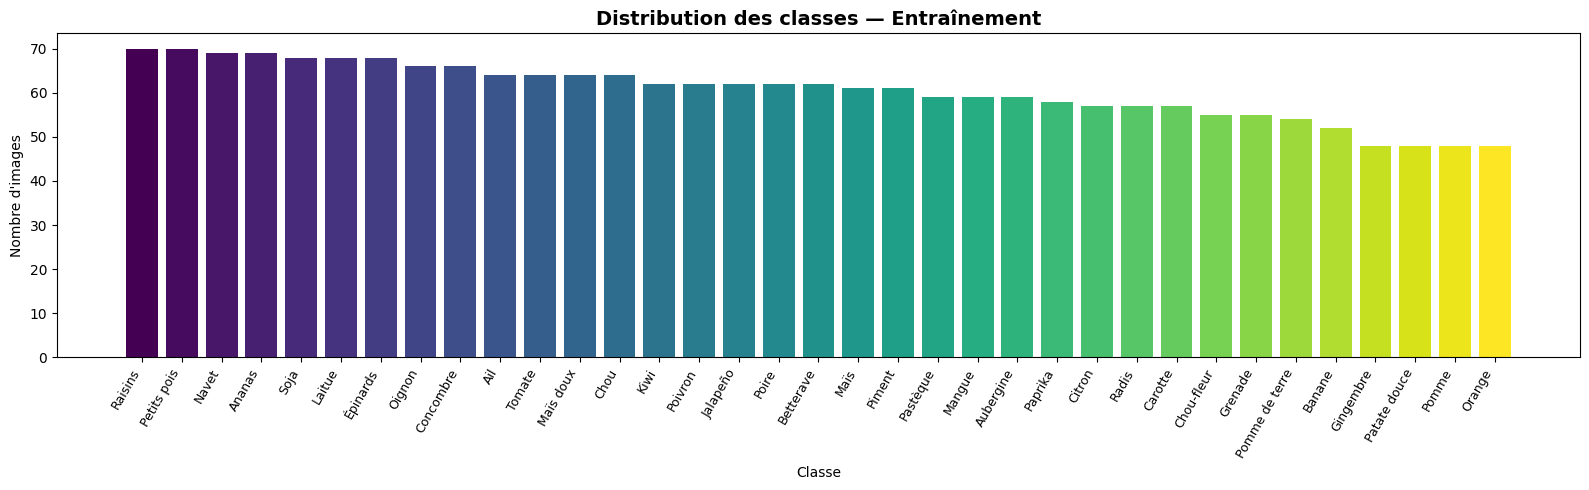

Min images par classe : 48 (Gingembre)
Max images par classe : 70 (Raisins)


In [6]:
# Distribution des classes (entraînement)
class_counts = train_df['classe_fr'].value_counts()

plt.figure(figsize=(16, 5))
bars = plt.bar(class_counts.index, class_counts.values, color=plt.cm.viridis(np.linspace(0, 1, len(class_counts))))
plt.xticks(rotation=60, ha='right', fontsize=9)
plt.title("Distribution des classes — Entraînement", fontsize=14, fontweight='bold')
plt.ylabel("Nombre d'images")
plt.xlabel("Classe")
plt.tight_layout()
plt.show()

print(f"Min images par classe : {class_counts.min()} ({class_counts.idxmin()})")
print(f"Max images par classe : {class_counts.max()} ({class_counts.idxmax()})")

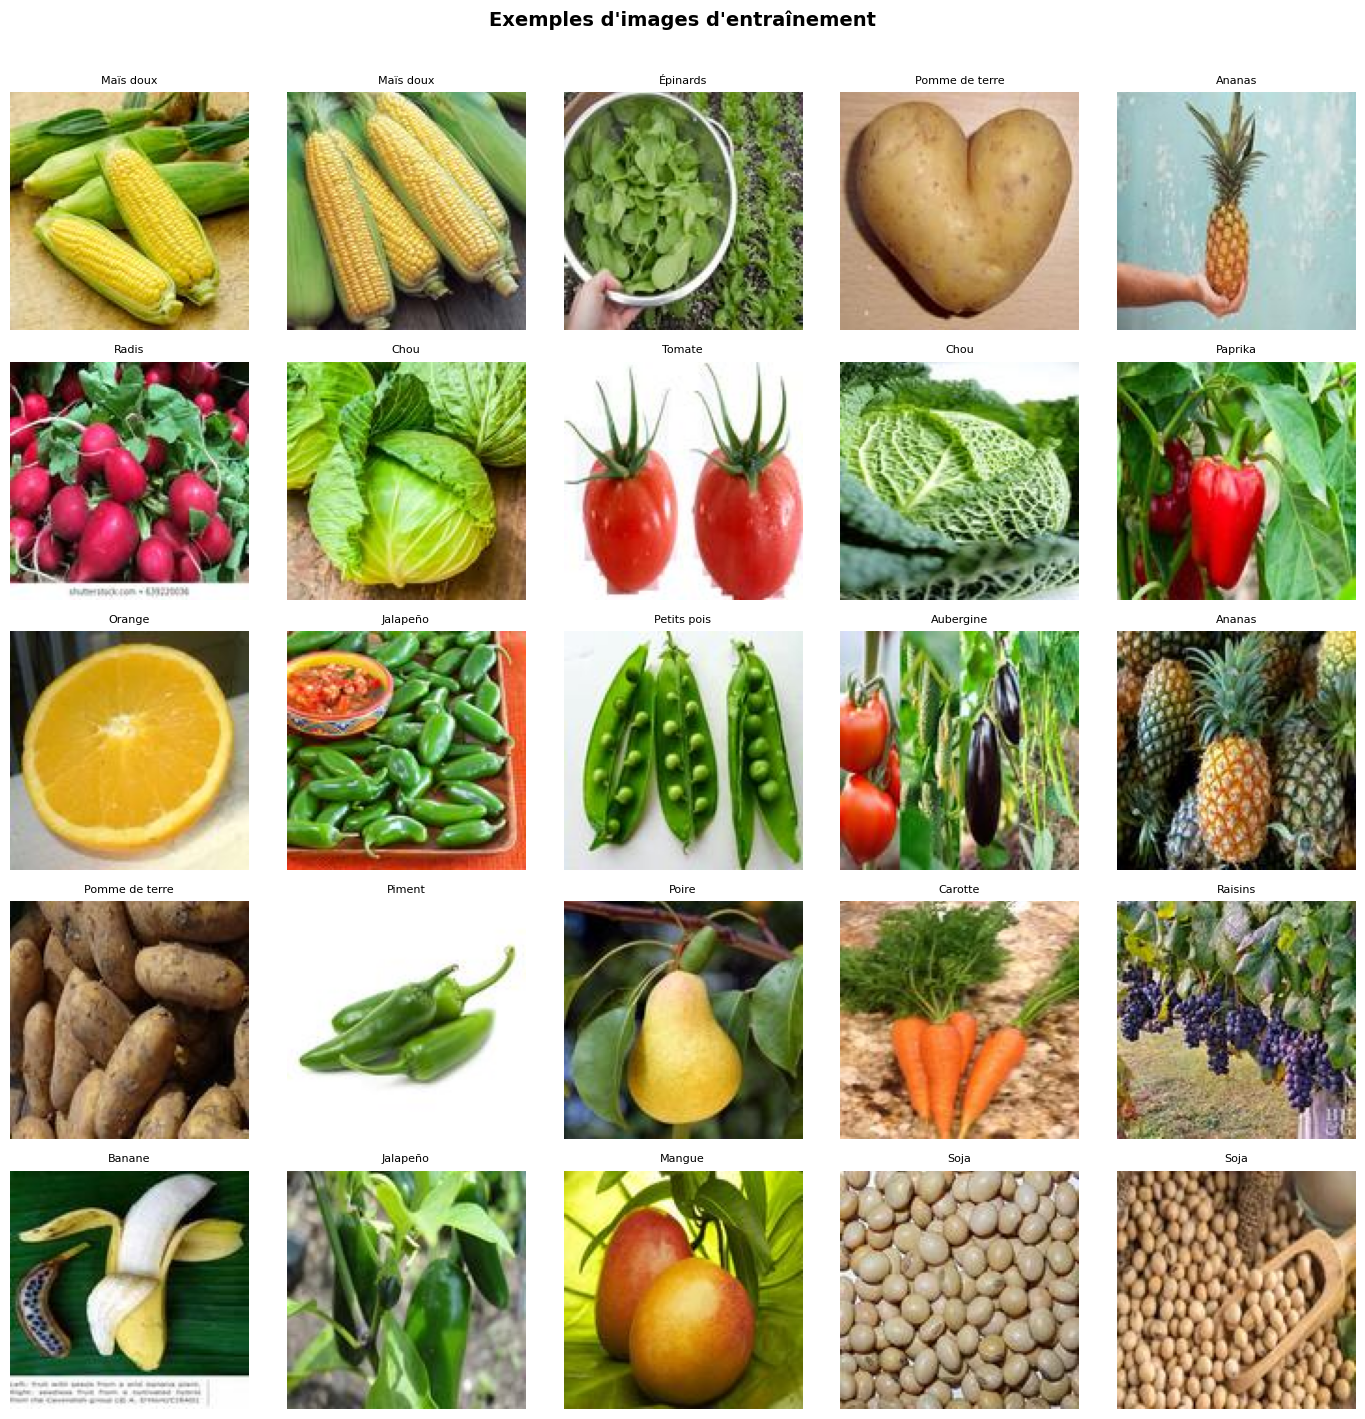

In [7]:
# Aperçu d'images originales (grille 5x5)
sample_files = train_df.sample(25, random_state=SEED)

plt.figure(figsize=(14, 14))
for i, (_, row) in enumerate(sample_files.iterrows()):
    img = load_img(os.path.join(TRAIN_DIR, row['fichier']), target_size=IMAGE_SIZE)
    plt.subplot(5, 5, i + 1)
    plt.imshow(img)
    plt.title(row['classe_fr'], fontsize=8)
    plt.axis('off')
plt.suptitle("Exemples d'images d'entraînement", fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

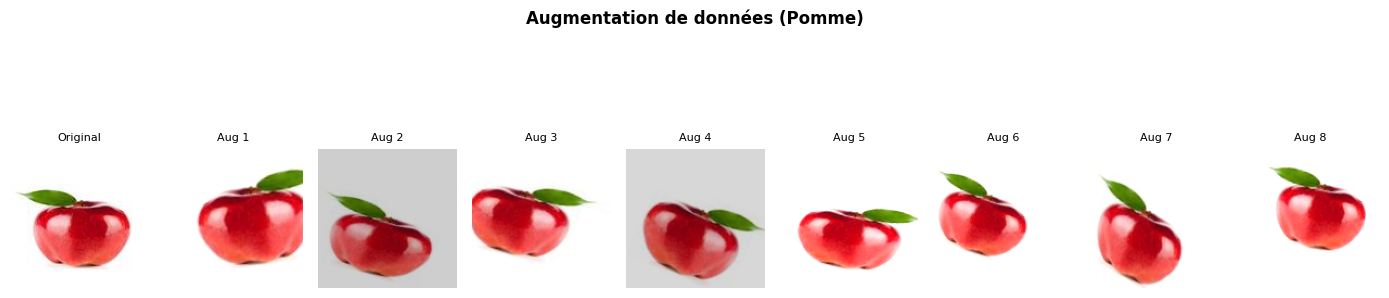

In [8]:
# Visualisation de l'augmentation de données
sample_row = train_df[train_df['classe_en'] == 'apple'].sample(1, random_state=SEED).iloc[0]
img_path   = os.path.join(TRAIN_DIR, sample_row['fichier'])
img        = load_img(img_path, target_size=IMAGE_SIZE)
img_array  = img_to_array(img)
img_array  = np.expand_dims(img_array, axis=0)

aug_gen = train_datagen.flow(img_array, batch_size=1, seed=SEED)

plt.figure(figsize=(14, 4))
plt.subplot(1, 9, 1)
plt.imshow(img)
plt.title('Original', fontsize=8)
plt.axis('off')

for j in range(8):
    aug_img = next(aug_gen)[0]
    plt.subplot(1, 9, j + 2)
    plt.imshow(aug_img)
    plt.title(f'Aug {j+1}', fontsize=8)
    plt.axis('off')

plt.suptitle("Augmentation de données (Pomme)", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Architecture du modèle CNN

In [13]:
def build_cnn(num_classes, input_shape=(128, 128, 3)):
    """
    Architecture CNN inspirée de detection-fruit.ipynb (model_1).
    5 blocs convolutifs avec BatchNormalization.
    Filtres : 128 → 128 → 64 → 128 → 32
    Tête Dense : 512 → 64 → softmax
    """
    model = models.Sequential([
        # ── Bloc 1 : 128 filtres ──────────────────────────────────────────
        layers.Conv2D(128, (3, 3), activation='relu', padding='same', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        # ── Bloc 2 : 128 filtres ──────────────────────────────────────────
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        # ── Bloc 3 : 64 filtres ───────────────────────────────────────────
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        # ── Bloc 4 : 128 filtres ──────────────────────────────────────────
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        # ── Bloc 5 : 32 filtres ───────────────────────────────────────────
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        # ── Tête de classification ────────────────────────────────────────
        layers.Flatten(),
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dense(64, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model


model = build_cnn(num_classes=NUM_CLASSES, input_shape=(IMAGE_HEIGHT, IMAGE_WIDTH, IMAGE_CHANNELS))

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 128, 128, 128)  │         3,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 128, 128, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 64, 64, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 8, 8, 32)       │        36,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 8, 8, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 4, 4, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 637,699 (2.43 MB)

 Trainable params: 635,587 (2.42 MB)

 Non-trainable params: 2,112 (8.25 KB)

## 6b. Visualisation de l'architecture

In [ ]:
# import matplotlib.image as mpimg

# arch_path = 'model/architecture.png'

# tf.keras.utils.plot_model(
#     model,
#     to_file=arch_path,
#     show_shapes=True,
#     show_layer_names=True,
#     show_layer_activations=True,
#     dpi=96,
#     expand_nested=False
# )

# img_arch = mpimg.imread(arch_path)
# plt.figure(figsize=(6, 22))
# plt.imshow(img_arch)
# plt.axis('off')
# plt.title("Architecture du CNN", fontsize=14, fontweight='bold')
# plt.tight_layout()
# plt.show()

# print(f"Architecture sauvegardée : {arch_path}")

NameError: name 'tf' is not defined

## 7. Callbacks

In [10]:
callbacks = [
    # Arrêt anticipé si la val_accuracy ne s'améliore plus
    EarlyStopping(
        monitor='val_accuracy',
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),
    # Réduction du learning rate sur plateau
    ReduceLROnPlateau(
        monitor='val_accuracy',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    ),
    # Sauvegarde du meilleur modèle
    ModelCheckpoint(
        MODEL_PATH,
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    )
]

print("Callbacks configurés :")
for cb in callbacks:
    print(f"  - {cb.__class__.__name__}")

Callbacks configurés :
  - EarlyStopping
  - ReduceLROnPlateau
  - ModelCheckpoint


## 8. Entraînement

In [11]:
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=validation_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    validation_steps=validation_generator.samples // BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

print(f"\nMeilleure val_accuracy : {max(history.history['val_accuracy']):.4f}")
print(f"Époque d'arrêt         : {len(history.history['accuracy'])}")

Epoch 1/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 535ms/step - accuracy: 0.0817 - loss: 3.6658
Epoch 1: val_accuracy improved from None to 0.04688, saving model to nicolas/model/best_model.keras

Epoch 1: finished saving model to nicolas/model/best_model.keras
94/94 ━━━━━━━━━━━━━━━━━━━━ 55s 551ms/step - accuracy: 0.1170 - loss: 3.3477 - val_accuracy: 0.0469 - val_loss: 3.5286 - learning_rate: 0.0010
Epoch 2/100
 1/94 ━━━━━━━━━━━━━━━━━━━━ 47s 515ms/step - accuracy: 0.2188 - loss: 2.7102
Epoch 2: val_accuracy improved from 0.04688 to 0.05625, saving model to nicolas/model/best_model.keras

Epoch 2: finished saving model to nicolas/model/best_model.keras
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.2188 - loss: 2.7102 - val_accuracy: 0.0562 - val_loss: 3.5240 - learning_rate: 0.0010
Epoch 3/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 511ms/step - accuracy: 0.2040 - loss: 2.8083
Epoch 3: val_accuracy did not improve from 0.05625
94/94 ━━━━━━━━━━━━━━━━━━━━ 49s 523ms/step - accuracy: 0.2059 - loss: 2

## 9. Graphiques de performance (Accuracy & Loss)

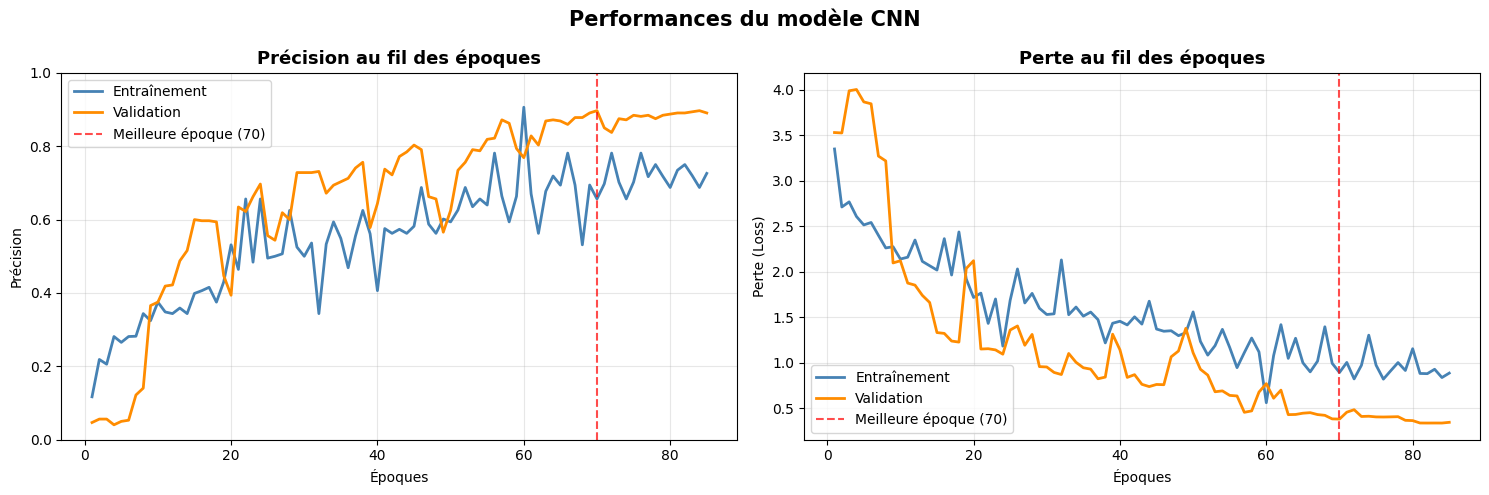

Accuracy finale (train)      : 0.7259
Accuracy finale (validation) : 0.8906
Loss finale (train)          : 0.8841
Loss finale (validation)     : 0.3430


In [12]:
acc     = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss    = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(acc) + 1)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ── Accuracy ──────────────────────────────────────────────────────────────────
axes[0].plot(epochs_range, acc,     label='Entraînement',  linewidth=2, color='steelblue')
axes[0].plot(epochs_range, val_acc, label='Validation',    linewidth=2, color='darkorange')
best_epoch = np.argmax(val_acc) + 1
axes[0].axvline(x=best_epoch, color='red', linestyle='--', alpha=0.7, label=f'Meilleure époque ({best_epoch})')
axes[0].set_title('Précision au fil des époques', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Époques')
axes[0].set_ylabel('Précision')
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].set_ylim([0, 1])

# ── Loss ──────────────────────────────────────────────────────────────────────
axes[1].plot(epochs_range, loss,     label='Entraînement', linewidth=2, color='steelblue')
axes[1].plot(epochs_range, val_loss, label='Validation',   linewidth=2, color='darkorange')
axes[1].axvline(x=best_epoch, color='red', linestyle='--', alpha=0.7, label=f'Meilleure époque ({best_epoch})')
axes[1].set_title('Perte au fil des époques', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Époques')
axes[1].set_ylabel('Perte (Loss)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Performances du modèle CNN', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Accuracy finale (train)      : {acc[-1]:.4f}")
print(f"Accuracy finale (validation) : {val_acc[-1]:.4f}")
print(f"Loss finale (train)          : {loss[-1]:.4f}")
print(f"Loss finale (validation)     : {val_loss[-1]:.4f}")

## 10. Évaluation sur le jeu de test

In [13]:
test_generator.reset()
test_loss, test_accuracy = model.evaluate(test_generator, verbose=1)
print(f"\nAccuracy sur le jeu de test : {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"Loss sur le jeu de test     : {test_loss:.4f}")

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 105ms/step - accuracy: 0.9026 - loss: 0.3576

Accuracy sur le jeu de test : 0.9026 (90.26%)
Loss sur le jeu de test     : 0.3576


## 11. Prédictions sur les images de test

In [ ]:
# Générer toutes les prédictions sur le jeu de test
test_generator.reset()
predictions_proba = model.predict(test_generator, verbose=1)
predicted_indices = np.argmax(predictions_proba, axis=1)

# Ajouter les prédictions au DataFrame
test_df['pred_en'] = [ENGLISH_NAMES[i] for i in predicted_indices]
test_df['pred_fr'] = [CLASS_NAMES_FR[ENGLISH_NAMES[i]] for i in predicted_indices]
test_df['correct'] = test_df['pred_en'] == test_df['classe_en']

print(f"Accuracy globale sur le test : {test_df['correct'].mean():.4f} ({test_df['correct'].sum()}/{len(test_df)})")
test_df.head(10)

In [ ]:
# Affichage de 18 images de test : image + vérité terrain + prédiction
n_display = 18
sample_test = test_df.sample(n_display, random_state=SEED).reset_index(drop=True)

plt.figure(figsize=(15, 20))
for i, row in sample_test.iterrows():
    img = load_img(os.path.join(TRAIN_DIR, row['fichier']), target_size=IMAGE_SIZE)
    plt.subplot(6, 3, i + 1)
    plt.imshow(img)
    plt.axis('off')

    couleur = 'green' if row['correct'] else 'red'
    label   = (
        f"Vérité : {row['classe_fr']}\n"
        f"Prédiction : {row['pred_fr']}"
    )
    plt.title(label, fontsize=8, color=couleur, fontweight='bold')

plt.suptitle(
    "Prédictions sur le jeu de test  (vert = correct, rouge = erreur)",
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

In [ ]:
# Affichage des cas mal classifiés
errors = test_df[~test_df['correct']].sample(min(9, (~test_df['correct']).sum()), random_state=SEED).reset_index(drop=True)

if len(errors) == 0:
    print("Parfait — aucune erreur sur cet échantillon !")
else:
    plt.figure(figsize=(12, 4 * ((len(errors) + 2) // 3)))
    for i, row in errors.iterrows():
        img = load_img(os.path.join(TRAIN_DIR, row['fichier']), target_size=IMAGE_SIZE)
        plt.subplot((len(errors) + 2) // 3, 3, i + 1)
        plt.imshow(img)
        plt.axis('off')
        plt.title(
            f"Vérité : {row['classe_fr']}\nPrédit : {row['pred_fr']}",
            fontsize=8, color='red', fontweight='bold'
        )
    plt.suptitle("Erreurs de classification", fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

## 12. Prédiction sur une image personnalisée (Top 5)

In [17]:
def predict_image(img_path, model, image_size, english_names, class_names_fr, top_k=5):
    """
    Classifie une image et affiche les top_k prédictions.

    Paramètres
    ----------
    img_path       : str  — chemin vers l'image
    model          : modèle Keras entraîné
    image_size     : tuple — (largeur, hauteur) attendues par le modèle
    english_names  : list  — classes dans l'ordre des indices du générateur
    class_names_fr : dict  — traduction EN → FR
    top_k          : int   — nombre de meilleures prédictions à afficher
    """
    # Chargement et prétraitement
    img       = load_img(img_path, target_size=image_size)
    img_array = img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Prédiction
    probas      = model.predict(img_array, verbose=0)[0]
    top_indices = np.argsort(probas)[::-1][:top_k]

    # ── Affichage visuel ─────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # Image
    axes[0].imshow(img)
    axes[0].axis('off')
    best_label = class_names_fr.get(english_names[top_indices[0]], english_names[top_indices[0]])
    axes[0].set_title(f"Prédiction : {best_label} ({probas[top_indices[0]]*100:.1f}%)",
                      fontsize=13, fontweight='bold')

    # Barplot Top K
    labels_fr  = [class_names_fr.get(english_names[i], english_names[i]) for i in top_indices]
    scores     = [probas[i] * 100 for i in top_indices]
    colors     = ['#2ecc71' if j == 0 else '#3498db' for j in range(top_k)]

    bars = axes[1].barh(labels_fr[::-1], scores[::-1], color=colors[::-1])
    axes[1].set_xlabel('Probabilité (%)')
    axes[1].set_title(f'Top {top_k} prédictions', fontsize=12, fontweight='bold')
    axes[1].set_xlim(0, 100)

    for bar, score in zip(bars, scores[::-1]):
        axes[1].text(
            min(bar.get_width() + 1, 95), bar.get_y() + bar.get_height() / 2,
            f'{score:.1f}%', va='center', fontsize=10, fontweight='bold'
        )

    plt.tight_layout()
    plt.show()

    # ── Résumé texte ─────────────────────────────────────────────────────────
    print(f"\n{'Rang':<6} {'Classe (FR)':<20} {'Classe (EN)':<20} {'Probabilité':>12}")
    print("-" * 62)
    for rank, idx in enumerate(top_indices, 1):
        en  = english_names[idx]
        fr  = class_names_fr.get(en, en)
        pct = probas[idx] * 100
        print(f"  {rank:<4} {fr:<20} {en:<20} {pct:>10.2f}%")

print("Fonction predict_image() prête.")

Fonction predict_image() prête.


In [ ]:
# ── Exemple : prédiction sur une image du jeu de test ─────────────────────────
sample_row   = test_df.sample(1, random_state=1).iloc[0]
exemple_path = os.path.join(TRAIN_DIR, sample_row['fichier'])
print(f"Image testée    : {exemple_path}")
print(f"Vérité terrain  : {sample_row['classe_fr']}")

predict_image(
    img_path       = exemple_path,
    model          = model,
    image_size     = IMAGE_SIZE,
    english_names  = ENGLISH_NAMES,
    class_names_fr = CLASS_NAMES_FR,
    top_k          = 5
)

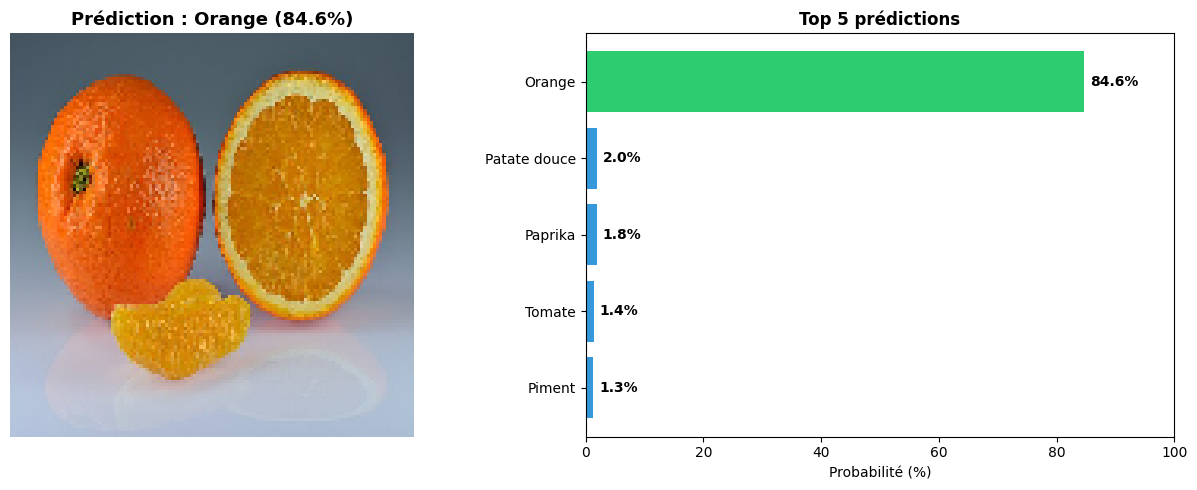


Rang   Classe (FR)          Classe (EN)           Probabilité
--------------------------------------------------------------
  1    Orange               orange                    84.61%
  2    Patate douce         sweetpotato                1.95%
  3    Paprika              paprika                    1.85%
  4    Tomate               tomato                     1.37%
  5    Piment               chilli pepper              1.32%


In [26]:
# ── Prédiction sur votre propre image ─────────────────────────────────────────
# Remplacez le chemin ci-dessous par le chemin vers votre image
MON_IMAGE = "/Users/nicolasguilland/Downloads/orange.jpg"  # <── modifiez ici

if os.path.exists(MON_IMAGE):
    predict_image(
        img_path       = MON_IMAGE,
        model          = model,
        image_size     = IMAGE_SIZE,
        english_names  = ENGLISH_NAMES,
        class_names_fr = CLASS_NAMES_FR,
        top_k          = 5
    )
else:
    print(f"Image non trouvée : {MON_IMAGE}")
    print("Modifiez la variable MON_IMAGE avec le chemin vers votre image.")

## 13. Sauvegarde finale du modèle

In [20]:
# Le meilleur modèle a déjà été sauvegardé automatiquement par ModelCheckpoint
print(f"Meilleur modèle sauvegardé : {MODEL_PATH}")

# Sauvegarde additionnelle du modèle final
final_path = 'model/final_model.keras'
model.save(final_path)
print(f"Modèle final sauvegardé    : {final_path}")

# Pour recharger plus tard :
# from tensorflow.keras.models import load_model
# model = load_model('model/best_model.keras')

Meilleur modèle sauvegardé : nicolas/model/best_model.keras
Modèle final sauvegardé    : model/final_model.keras
